Enlace al fork: https://github.com/BloodCrests/baile.git

<center>
  <h1><b>UNIVERSIDAD MICHOACANA DE SAN NICOLÁS DE HIDALGO</b></h1>
  <hr width="80%">
  <br>
  <h3><b>PROYECTO 1</b></h3>
  <br><br>
  
  <p><b>MATERIA:</b><br>INTELIGENCIA ARTIFICIAL</p>
  <br>
  
  <p><b>PROYECTO:</b><br>PEÓN LLEGANDO A LA CORONACIÓN</p>
  <br><br>

  <p><b>ALUMNOS:</b><br>
  NATAN DOMINGUEZ ORTIZ - 1911514E<br>
  EDUARDO RANGEL MEJIA - 1912353X<br>
  JOSE CARLOS MARTINEZ MORENO - 1912785F</p>
</center>


# **2.Descripción del problema**
El problema consiste en encontrar un camino para un peón de ajedrez que parte desde una posición inicial dentro de un tablero de **`8x8 casillas`** y debe llegar hasta la octava fila para alcanzar la coronación.

Durante su recorrido, el peón encuentra piezas adversarias estáticas que pueden modificar las opciones disponibles. Una pieza ubicada directamente frente al peón puede bloquear su avance, mientras que una pieza ubicada en una de sus diagonales puede ser capturada, permitiendo que el peón continúe su recorrido desde una nueva posición.

El objetivo es determinar una secuencia válida de movimientos que permita el peón llegar a la octava fila.

A continuación veremos un tablero de ejemplo:

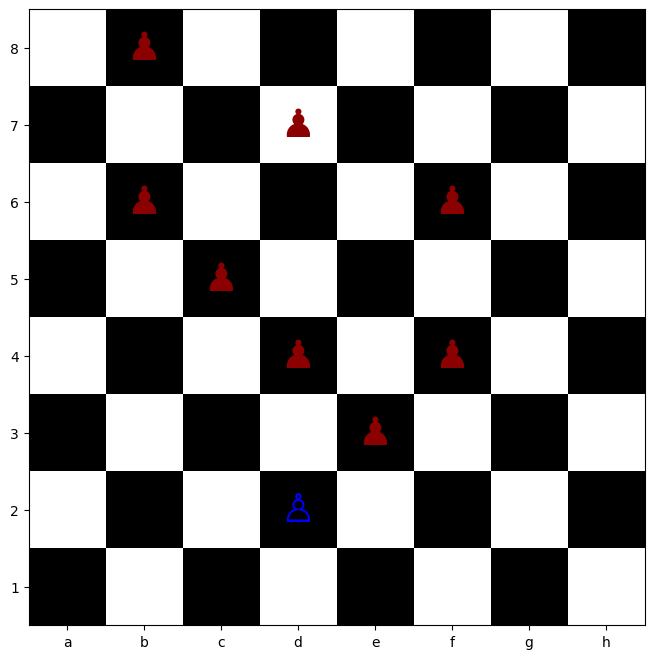

#3. Modelado formal

1. **Estado**

El estado del problema se representa mediante una tupla formada por dos elementos:

`estado = (posicion_peon, enemigos)`

La posición del peón se representa mediante:

`(fila, columna)`

Mientras que las piezas enemigas se almacenan utilizando un frozenset de posiciones.

Por ejemplo:

```
estado_inicial = (
    (1,3),
    frozenset([(3,4),(3,5),(4,2),(5,1)])
)
```

Esto significa que el `peón` comienza en la fila 1, columna 3, y que existen piezas enemigas en las posiciones indicadas.

Justificación: Se decidió representar el estado de esta manera porque solamente necesitamos conocer dos cosas para determinar los movimientos disponibles: la posición actual del peón y la ubicación de las piezas enemigas. El `frozenset` permite almacenar las posiciones de los enemigos y modificar el conjunto cuando el peón realiza una captura.

2. **Sucesor**

La función sucesores genera los estados que pueden alcanzarse a partir de la posición actual del peón.

Se consideran tres tipos de movimientos:

- Avance inicial de dos casillas, cuando el peón se encuentra en su posición inicial.
- Avance de una casilla hacia adelante, siempre que la casilla esté libre.
- Captura en diagonal, cuando existe una pieza enemiga en alguna de las dos diagonales delanteras.

Por ejemplo, si el peón se encuentra en:

<center>(3,3)</center>

puede revisar las siguientes posiciones:

**Avance:              (4,3)**

**Diagonal izquierda:  (4,2)**

**Diagonal derecha:    (4,4)**


El movimiento hacia adelante solamente se genera si la casilla está libre. Las capturas diagonales solamente se generan cuando existe una pieza enemiga en esa posición.

Cuando se realiza una captura, la pieza enemiga se elimina del nuevo estado:

**nuevos_enemigos = enemigos - {casilla_izq}**

Justificación: Se implementaron estos movimientos porque representan las acciones permitidas para el peón dentro de las reglas establecidas para el problema. Además, se comprueba que las posiciones se encuentren dentro del tablero para evitar generar estados inválidos.

3. **Meta**

La función es_meta determina cuándo el problema ha sido resuelto:

```
def es_meta(nodo, estado_meta):

    estado = nodo.state
    peon, enemigos = estado

    fila = peon[0]
    columna = peon[1]

    if fila == 7 and 0 <= columna <= 7:
        return True

    return False
```
La meta se alcanza cuando el peón llega a la fila 7, que representa la octava fila del tablero debido a que utilizamos índices desde 0 hasta 7.

Por lo tanto, cualquiera de estas posiciones representa una solución:

`(7,0)  (7,1)  (7,2)  (7,3)
(7,4)  (7,5)  (7,6)  (7,7)`

Justificación: El objetivo del problema es que el peón llegue a la octava fila para coronarse. Por esta razón, no es necesario establecer una columna específica como destino, ya que cualquier posición de la última fila representa una solución válida.

El parámetro `estado_meta` se mantiene porque `TreeSearch` requiere que la función de meta reciba el nodo actual y el estado meta, aunque en este problema no necesitamos utilizar directamente `estado_meta`.

4. **Heurística**

Para la búsqueda `A*` se utilizaron diferentes funciones heurísticas con el objetivo de comparar su comportamiento.

4.1 **Heurística de distancia**
```
def heuristica(nodo, estado_meta):

    estado = nodo.state
    peon, enemigos = estado

    fila = peon[0]

    return 7 - fila
```
Esta heurística calcula cuántas filas le faltan al peón para llegar a la fila 7.

Por ejemplo, si el peón se encuentra en la fila 3:

h(n) = 7 - 3 = 4

Esto significa que se estima que faltan cuatro filas para llegar a la meta.

Justificación: Se utiliza la distancia vertical porque el objetivo principal del problema es hacer avanzar al peón hasta la octava fila. De esta manera, A* obtiene una estimación de qué tan cerca se encuentra cada estado de la meta.

4.2 **Heurística cero**
def heuristica_cero(nodo, estado_meta):
    return 0

Esta función siempre devuelve 0, por lo que no proporciona información sobre la distancia entre el estado actual y la meta.

Justificación: Se utiliza como punto de comparación para observar el comportamiento de A* cuando no cuenta con información heurística. Esto permite comparar sus resultados con los obtenidos utilizando una heurística que sí considera la distancia hacia la meta.

4.3 **Heurística de avance y enemigos**
def heuristica_avanzar_adelante(nodo, estado_meta):

    peon, enemigos = nodo.state
    fila, columna = peon

    h_fila = 7 - fila

    enemigos_adelante = sum(
        1 for f, c in enemigos if f > fila
    )

    return h_fila + enemigos_adelante

Esta heurística combina dos factores:

Distancia hasta la meta: 7 - fila.
Cantidad de enemigos que se encuentran por delante del peón.

La estimación se calcula mediante:

h(n) = distancia a la meta + enemigos por delante

Por ejemplo, si al peón le faltan 4 filas para llegar a la meta y existen 3 enemigos en filas superiores:

h(n) = 4 + 3 = 7

Justificación: Para nuestro proyecto decidimos utilizar principalmente la **heurística de distancia (4.1)**, ya que es sencilla de implementar y fácil de comprender. Esta heurística permite que `A*` tenga una estimación directa de las filas que le faltan al peón para llegar a la coronación.

Sin embargo, al compararla con la **heurística de avance y enemigos (4.3)**, esta última proporciona mayor información al algoritmo, ya que además de considerar la distancia hacia la meta, toma en cuenta la cantidad de enemigos que se encuentran por delante. Por lo tanto, la heurística **4.3 puede ofrecer una guía más completa para este problema**, aunque la 4.1 fue la elegida para nuestra implementación principal debido a su simplicidad.

# **4. Estimación del tamaño de la búsqueda**

Antes de implementar los algoritmos de búsqueda, es importante estimar qué tan grande puede ser el árbol de búsqueda. Para esto se consideran principalmente dos valores: el **factor de ramificación `b`**, que indica cuántos sucesores puede generar un estado, y la **profundidad de la solución `d`**, que indica aproximadamente cuántos movimientos necesita el peón para llegar a la coronación.

### **Factor de ramificación `b`**

En nuestro problema, un peón puede generar como máximo **3 sucesores** desde una posición:

* Un movimiento hacia adelante.
* Una captura diagonal hacia la izquierda.
* Una captura diagonal hacia la derecha.

Por lo tanto, podemos considerar:

```text
b ≈ 3
```

Sin embargo, en la práctica normalmente tendrá menos de 3 sucesores, debido a que puede encontrar casillas bloqueadas, no tener enemigos en las diagonales o encontrarse en los límites del tablero.

### **Profundidad de la solución `d`**

El peón comienza en la fila `1` y debe llegar a la fila `7`. Si solamente avanzara una casilla en cada movimiento, necesitaría aproximadamente:

```text
d ≈ 6 movimientos
```

En algunos casos puede avanzar dos casillas desde su posición inicial, por lo que una solución puede ser incluso más corta. Las capturas diagonales también pueden cambiar el recorrido.

Por lo tanto, podemos considerar aproximadamente:

```text
d ≈ 6
```

### **Estimación**

Utilizando la expresión:

```text
b^d
```

tenemos:

```text
3^6 = 729
```

Esto significa que, en un caso aproximado sin considerar estados repetidos, una búsqueda no informada podría explorar del orden de **729 nodos** hasta alcanzar una profundidad de 6.

Este número es relativamente pequeño, por lo que el problema resulta **viable para realizar búsquedas BFS y DFS**, además de poder comparar su comportamiento con `A*`. Además, como el tablero tiene un tamaño limitado y los enemigos permanecen estáticos, el número de estados posibles también está acotado.

La estimación nos permite saber desde antes de programar que el problema no debería generar un árbol de búsqueda excesivamente grande y que es adecuado para comparar diferentes estrategias de búsqueda.

#**5. Implementación**

In [ ]:
import urllib.request
url = "https://raw.githubusercontent.com/BloodCrests/baile/refs/heads/master/src/SimpleSearch.py"

urllib.request.urlretrieve(url, 'SimpleSearch.py')

import pandas as pd
import time
import matplotlib.pyplot as plt #Libreria para graficar
import pandas as pd #libreria para manipulacion del dataframe
import SimpleSearch as sp#libreria para algoritmos de busqueda
from SimpleSearch import Node #refernciar la clase node

Ejecutar el bloque de codigo para ver las diferencias entre Fácil, Medio y Difícil

In [24]:
estado_inicial=(
    (1,3),
    frozenset([(2,4),(3,3)])
)

In [ ]:
estado_inicial=(
    (1,3),
    frozenset([(3,4),(3,5),(4,2),(5,1)])
)

In [ ]:
estado_inicial=(
    (1,3),
    frozenset([(2,4),(3,3),(3,5),(4,2),(5,1),(5,5),(6,3),(7,1)])
)

In [ ]:
def plot_tablero(estado):
    peon, enemigos = estado
    tablero=[[(i+j)%2 for j in range(8)] for i in range(8)]#Crea una matriz 8x8 que representa el tablero de ajedrez.
    fig, ax=plt.subplots(figsize=(8,8))#Muestra la matriz tablero como una imagen en los ejes. cmap="gray" asigna un mapa de colores en escala de grises, donde los valores 0 y 1
    ax.imshow(tablero, cmap="gray")
    ax.set_xlim(-0.5, 7.5)#Establece los límites del eje X desde -0.5 hasta 7.5. Esto asegura que el tablero de 8x8
    ax.set_ylim(-0.5, 7.5)#verticalidad
    ax.set_xticks(range(8))#Establece los límites del eje X desde -0.5 hasta 7.5. Esto asegura que el tablero de 8x8
    ax.set_yticks(range(8))#Define las posiciones de las marcas del eje Y
    ax.set_xticklabels(["a", "b", "c", "d", "e", "f", "g", "h"])
    ax.set_yticklabels(["1", "2", "3", "4", "5", "6", "7", "8"])

    # Piezas enemigas
    for fila, col in enemigos:
        ax.text(col, fila, "♟", ha="center", va="center", fontsize=28, color="darkred")

    # Peón
    fila_p, col_p = peon
    ax.text(col_p, fila_p, "♙", ha="center", va="center", fontsize=28, color="blue")

    plt.show()

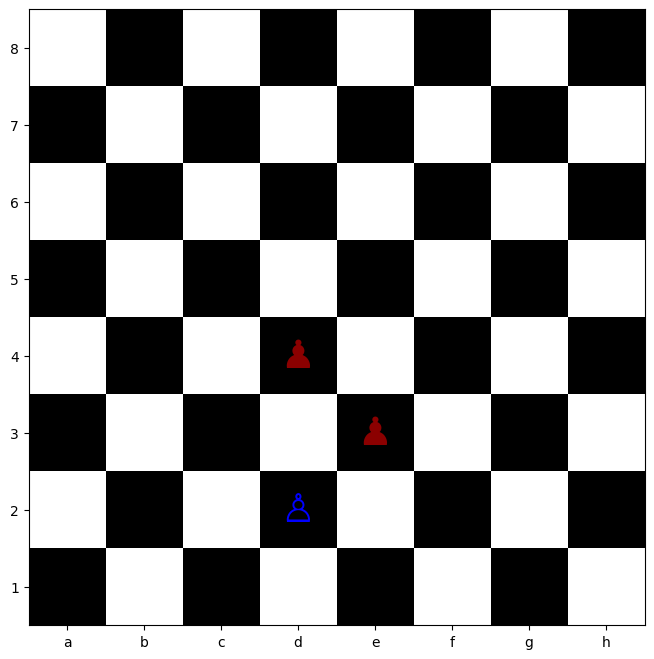

In [25]:
plot_tablero(estado_inicial)

In [ ]:
def sucesores(estado):#Define una función llamada sucesores que toma un argumento estado.
#Este estado es una tupla que representa la situación actual del tablero, conteniendo la posición del peón y las posiciones de los enemigos.
    posicion, enemigos = estado
    fila = posicion[0]#Extrae la fila actual del peón de la variable posicion.
    columna = posicion[1] #Extrae la columna actual del peón de la variable posicion
    sucesores = [] #Aquí se irán añadiendo todos los posibles nuevos estados

    if fila == 1: #Esta condición verifica si el peón se encuentra en su posición inicia
      nueva_posicion = (fila + 2, columna) #Calcula la posición a la que llegaría el peón si avanza dos casillas hacia adelante
      casilla1 = (fila + 1, columna) #Calcula la posición a la que llegaría el peón si avanza dos casillas hacia adelante.
      casilla2 = (fila + 2, columna) #Define la posición de la casilla final, dos casillas delante del peó
      if casilla1 not in enemigos and casilla2 not in enemigos: #Verifica si ambas casillas (la intermedia y la final) están libres de enemigos.
      #Si hay un enemigo en cualquiera de ellas, el peón no puede avanzar dos casillas.
        nuevo_estado = (nueva_posicion, enemigos)#Si el avance de dos casillas es válido, crea un nuevo_estado con la nueva_posicion del peón y el mismo conjunto de enemigos
        sucesores.append(nuevo_estado) #Añade este nuevo_estado a la lista de sucesores.


    nueva_posicion = (fila + 1, columna)#Calcula la posición para un avance de una casilla hacia adelante.
    if nueva_posicion not in enemigos and fila + 1 < 8: #Verifica dos condiciones para este movimiento: nueva_posicion not in enemigos: Que la casilla directamente enfrente del peón esté libre.
    # fila + 1 < 8: Que el peón no se salga del tablero al avanzar (la fila 7 es la última fila válida).Verifica dos condiciones para este movimiento:
      nuevo_estado = (nueva_posicion, enemigos) #Si el avance de una casilla es válido, crea un nuevo_estado
      sucesores.append(nuevo_estado)#Si el avance de una casilla es válido, crea un nuevo_estado

    casilla_izq = (fila + 1, columna - 1)#Calcula la posición de la casilla diagonal izquierda frontal.
    if (columna - 1 >= 0 and fila + 1 < 8 and casilla_izq in enemigos):#Verifica las condiciones para una captura diagonal izquierda:
                                                                      #columna - 1 >= 0: Que la casilla no se salga del tablero por el lado izquierdo.
                                                                      #fila + 1 < 8: Que la casilla no se salga del tablero por arriba.
                                                                      # casilla_izq in enemigos: Que exista un enemigo en esa casilla.

        nuevos_enemigos = enemigos - {casilla_izq} #Si se realiza la captura, crea un nuevo frozenset de enemigos, eliminando la pieza capturada de la casilla_izq.
        nuevo_estado = (casilla_izq, nuevos_enemigos) #Crea un nuevo_estado con el peón en la casilla_izq y el conjunto actualizado de nuevos_enemigos
        sucesores.append(nuevo_estado) #Añade este nuevo_estado a la lista de sucesores.

    casilla_der = (fila + 1, columna + 1)#calcula la posición de la casilla diagonal derecha frontal
    if (columna + 1 < 8 and fila + 1 < 8 and casilla_der in enemigos):#Verifica las condiciones para una captura diagonal derecha:
        nuevos_enemigos = enemigos - {casilla_der}#Si se realiza la captura, crea un nuevo frozenset de enemigos, eliminando la pieza capturada de la casilla_der
        nuevo_estado = (casilla_der, nuevos_enemigos)
        sucesores.append(nuevo_estado)

    return sucesores

In [ ]:
def successor(node):
    return [Node(estado, node, node.depth + 1) for estado in sucesores(node.state)]

In [ ]:
def es_meta(nodo, estado_meta): #definimos la funcion meta que recibira el nodo, y un estado meta
                                #nodo: representa la posición actual que el algoritmo está revisando
                                #estado_meta: representa el estado objetivo que busca alcanzar

    estado = nodo.state

    peon, enemigos = estado

    fila = peon[0]
    columna = peon[1] #posiciones del peon y enemigos

    if fila == 7 and 0 <= columna <= 7: # La meta se cumple cuando el peón alcanza la última fila del tablero regresa verdadero en caso de que si alcance
        return True

    return False #en caso de no llegar ala fila 7 y columna 7 retornara que no alcanzo el estado meta

La función `es_meta` utiliza `TreeSearch` que trabaja con objetos `Node`, por lo que la función recibe el nodo y obtiene el estado mediante `nodo.state`.

Utilizamos el argumento `es_meta` en la función porque `TreeSearch` espera que la función `es_meta` reciba dos parámetros: el nodo actual y el estado meta.

En nuestro problema, no necesitamos utilizar directamente `estado_meta`, porque la condición para ganar es simplemente que el peón llegue a la octava fila:

<center>if fila == 7:</center>

<center>return True </center>

Sin embargo, no podemos eliminar el parámetro porque `TreeSearch` lo envía cuando llama a `es_meta`. Si lo eliminamos, la función recibiría más argumentos de los que acepta y Python genera un error.

Esto permite adaptar la función al formato que utiliza `SimpleSearch.py`, que llama a la meta con dos parámetros: el nodo actual y el estado meta. La condición principal es la misma: comprobar si el peón llegó a la fila 7.


In [ ]:
def heuristica(nodo, estado_meta):

    estado = nodo.state

    peon, enemigos = estado

    fila = peon[0]

    return 7 - fila

La `heurística` calcula una estimación de cuántas filas le faltan al peón para llegar a la fila 7, que es la meta. Para esto se utiliza `7 - fila`. Por ejemplo, si el peón está en la fila 3, la `heurística` devuelve 4, porque faltan cuatro filas para llegar a la fila 7. Cuando el peón llega a la fila 7, la `heurística` vale 0.

In [ ]:
def heuristica_cero(nodo, estado_meta):
    return 0

La función `heuristica_cero` recibe el `nodo` y el `estado_meta` porque mantiene la estructura que requiere el algoritmo `A*`. Sin embargo, **no utiliza ninguno de los dos parámetros**, ya que siempre devuelve `0`. Esto significa que no proporciona ninguna estimación sobre qué tan cerca está el peón de la meta. Al utilizar esta función en `A*`, la búsqueda se comporta como una búsqueda **sin información heurística**, permitiendo comparar su funcionamiento con una heurística que sí considera la distancia o los obstáculos del tablero.


In [ ]:
def heuristica_avanzar_adelante(nodo, estado_meta):
  peon, enemigos = nodo.state
  fila, columna = peon

  # Distancia base a la fila meta (7)
  h_fila = 7 - fila

  # Contar cuántos enemigos están físicamente más adelante
  enemigos_adelante = sum(1 for f, c in enemigos if f > fila)

  return h_fila + enemigos_adelante

 Heurística Enemigos Adelante: `heuristica_avanzar_adelante`

Esta función heurística calcula el costo estimado `h(n)` para guiar al peón hacia su coronación en la fila final `7`, combinando dos factores estratégicos clave:

1. **Distancia base vertical `(7 - fila)`:** Mide los pasos mínimos que le faltan al peón para avanzar en línea recta hasta la meta.
2. **Penalización por obstáculos frontales (`enemigos_adelante`):** Cuenta cuántas piezas enemigas se encuentran físicamente en filas superiores `(f > fila)`, sumando peso a los estados bloqueados.

**Comportamiento en el algoritmo A\*:**
Al tomar en cuenta los obstáculos que se encuentran frente al peón, la heurística ayuda a A* a elegir caminos que tengan menos bloqueos. De esta manera, el algoritmo puede buscar rutas donde el peón pueda avanzar o realizar capturas en diagonal, evitando explorar tantos caminos innecesarios y encontrando la solución con menos iteraciones.

Comprobar las diferencias entre los diferentes algoritmos de busqueda, mostrando una tabla para comparar las iteraciones que hace cada uno

Número de sucesores: 2
Estado del primer sucesor:


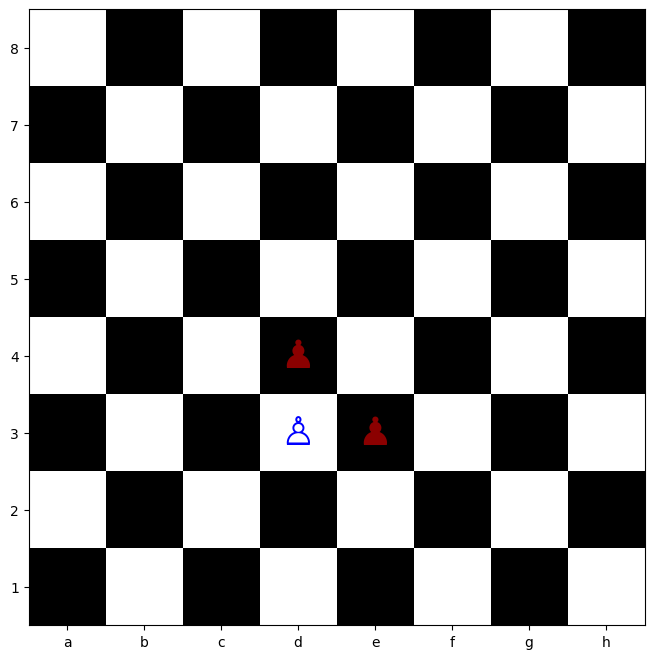

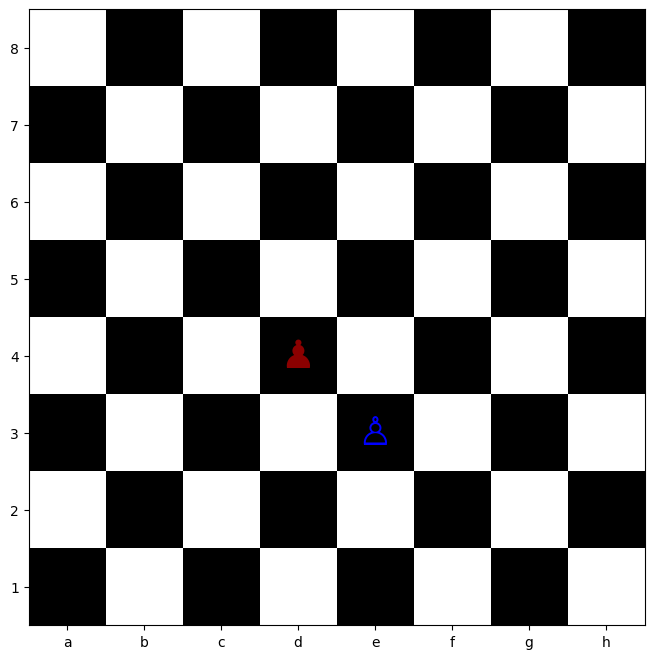

In [ ]:
nodo_inicial = sp.Node(estado_inicial) #Crea una instancia de un objeto Node
S = successor(nodo_inicial)#Se le pasa como argumento el estado_inicial definido previamente (que contiene la posición del peón y la de los enemigos).

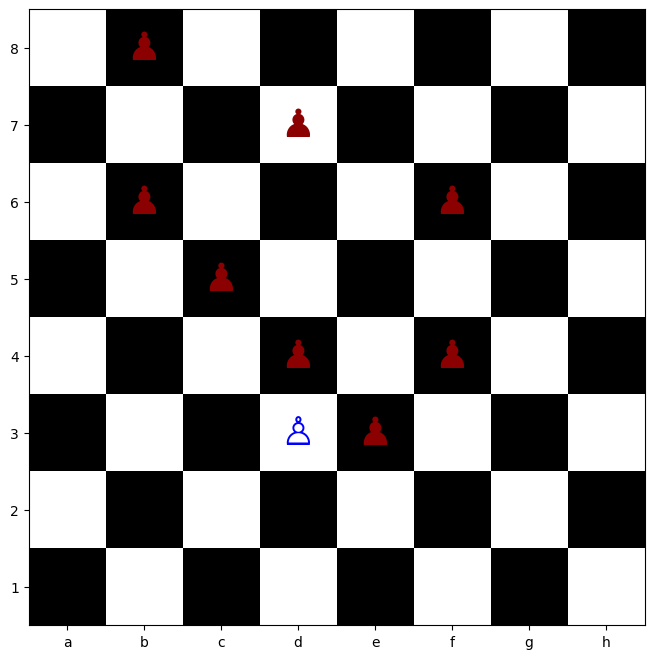

In [ ]:
plot_tablero(S[0].state)

In [ ]:
#DISEÑO PARA COMPARAR EFICIENCIA DE ESTADOS
bfs=sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="bfs")
dfs=sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="dfs")
bas=sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="a*", heuristic=heuristica)
bas_cero=sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="a*", heuristic=heuristica_cero)
bas_avanzar = sp.TreeSearch( nodo_inicial, successor, es_meta, strategy="a*", heuristic=heuristica_avanzar_adelante)
#SE CREAN VARIAS INSTACIAS DE LA LIBREARIA SIMPLESEARCH PARA REALIZAR BUSQUEDA DE ARBOLES DE ESTADOS, se define en esto el nodo inical, sucesor, meta, y que estrategia se israra

r1=bfs.find()
r2=dfs.find()
r3=bas.find()
r4=bas_cero.find() #retornan los valores de la estimacion de costo para llegar a la meta
r5=bas_avanzar.find()

resultados=pd.DataFrame({"Busqueda":["BFS", "DFS", "A*", "A* h=0", "A*_avanzar"], "Iteraciones":[bfs.iterations, dfs.iterations, bas.iterations, bas_cero.iterations, bas_avanzar.iterations]})
#guarda el número de iteraciones que cada algoritmo necesitó para encontrar la solución

print(resultados) #imprime los resultados

     Busqueda  Iteraciones
0         BFS           11
1         DFS            6
2          A*           11
3      A* h=0           11
4  A*_avanzar           11


## 6. Experimentos y Protocolo Experimental

Para evaluar y comparar de manera justa el rendimiento de las distintas estrategias de búsqueda, se definieron **tres instancias de dificultad creciente** basadas en la densidad y posición de los peones enemigos en el tablero de $8\times8$:

* **Instancia Fácil (`fácil`):**
  * *Configuración:* Posición inicial del peón en `(1, 3)` con un conjunto reducido de enemigos bloqueando de forma muy leve `frozenset([(2, 4), (3, 3)])`.
  * *Objetivo:* Servir de prueba base donde el espacio de estados es pequeño y directo.

* **Instancia Media (`media`):**
  * *Configuración:* Posición inicial en `(1, 3)` con una distribución intermedia de obstáculos `frozenset([(3, 3), (3, 5), (4, 2), (5, 1)])`.
  * *Objetivo:* Medir cómo reaccionan los algoritmos ante bloqueos laterales y la necesidad de elegir rutas diagonales.

* **Instancia Difícil (`difícil`):**
  * *Configuración:* Posición inicial en `(1, 3)` con una barrera densa de múltiples enemigos `frozenset([(2, 4), (3, 3), (3, 5), (4, 2), (5, 1), (5, 5), (6, 3), (7, 1)])`.
  * *Objetivo:* Poner a prueba la eficiencia de la heurística avanzada para evitar problemas severos.

**Parámetros de ejecución:**
* **Límite de iteraciones:** Se estableció un límite estricto de `max_iter = 500000` para todas las pruebas.
* **Entorno:** Ejecutado en Google Colab (Python 3, entorno estándar de hardware asignado por la plataforma).

In [ ]:
MAX_ITER = 500000

def fila(nombre_instancia, nombre_estrategia, buscador, r, tiempo):
  if r is None:
    return {"Instancia": nombre_instancia, "Estrategia": nombre_estrategia,
                "Nodos expandidos": buscador.iterations, "Tiempo (s)": round(tiempo, 4),
                "Longitud": None, "Costo g": None}
  return  {"Instancia": nombre_instancia, "Estrategia": nombre_estrategia,
            "Nodos expandidos": buscador.iterations, "Tiempo (s)": round(tiempo, 4),
            "Longitud": len(r.getPath()) - 1, "Costo g": r.cost}

In [ ]:
filas = []
#Instancia fácil
estado_inicial = ((1, 3), frozenset([(2, 4), (3, 3)]))
nodo_inicial = sp.Node(estado_inicial)

bfs = sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="bfs")
dfs = sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="dfs")
bas_cero = sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="a*", heuristic=heuristica_cero)
bas = sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="a*", heuristic=heuristica)
bas2 = sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="a*", heuristic=heuristica_avanzar_adelante)

t0 = time.time(); r1 = bfs.find(max_iter=MAX_ITER); filas.append(fila("facil", "BFS", bfs, r1, time.time() - t0))
t0 = time.time(); r2 = dfs.find(max_iter=MAX_ITER); filas.append(fila("facil", "DFS", dfs, r2, time.time() - t0))
t0 = time.time(); r3 = bas_cero.find(max_iter=MAX_ITER); filas.append(fila("facil", "A* (h=0)", bas_cero, r3, time.time() - t0))
t0 = time.time(); r4 = bas.find(max_iter=MAX_ITER); filas.append(fila("facil", "A* (h=7-fila)", bas, r4, time.time() - t0))
t0 = time.time(); r5 = bas2.find(max_iter=MAX_ITER); filas.append(fila("facil", "A* (h=(7-fila)+enemigos_adelante)", bas2, r5, time.time() - t0))

#Tabla final
tabla_resultados = pd.DataFrame(filas)
tabla_resultados

,Instancia,Estrategia,Nodos expandidos,Tiempo (s),Longitud,Costo g
0,facil,BFS,11,0.0001,6,6
1,facil,DFS,6,0.0001,6,6
2,facil,A* (h=0),11,0.0002,6,6
3,facil,A* (h=7-fila),11,0.0001,6,6
4,facil,A* (h=(7-fila)+enemigos_adelante),11,0.0001,6,6


In [ ]:
filas = []
#Instancia media
estado_inicial = ((1, 3), frozenset([(3, 4), (3, 5), (4, 2), (5, 1)]))
nodo_inicial = sp.Node(estado_inicial)

bfs = sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="bfs")
dfs = sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="dfs")
bas_cero = sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="a*", heuristic=heuristica_cero)
bas = sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="a*", heuristic=heuristica)
bas2 = sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="a*", heuristic=heuristica_avanzar_adelante)

t0 = time.time(); r1 = bfs.find(max_iter=MAX_ITER); filas.append(fila("media", "BFS", bfs, r1, time.time() - t0))
t0 = time.time(); r2 = dfs.find(max_iter=MAX_ITER); filas.append(fila("media", "DFS", dfs, r2, time.time() - t0))
t0 = time.time(); r3 = bas_cero.find(max_iter=MAX_ITER); filas.append(fila("media", "A* (h=0)", bas_cero, r3, time.time() - t0))
t0 = time.time(); r4 = bas.find(max_iter=MAX_ITER); filas.append(fila("media", "A* (h=7-fila)", bas, r4, time.time() - t0))
t0 = time.time(); r5 = bas2.find(max_iter=MAX_ITER); filas.append(fila("media", "A* (h=(7-fila)+enemigos_adelante)", bas2, r5, time.time() - t0))

#Tabla final
tabla_resultados = pd.DataFrame(filas)
tabla_resultados

,Instancia,Estrategia,Nodos expandidos,Tiempo (s),Longitud,Costo g
0,media,BFS,14,0.0002,5,5
1,media,DFS,6,0.0001,6,6
2,media,A* (h=0),14,0.0001,5,5
3,media,A* (h=7-fila),10,0.0001,5,5
4,media,A* (h=(7-fila)+enemigos_adelante),5,0.0001,5,5


In [ ]:
filas = []
#Instancia difícil
estado_inicial = ((1, 3), frozenset([(2, 4), (3, 3), (3, 5), (4, 2), (5, 1), (5, 5), (6, 3), (7, 1)]))
nodo_inicial = sp.Node(estado_inicial)

bfs = sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="bfs")
dfs = sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="dfs")
bas_cero = sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="a*", heuristic=heuristica_cero)
bas = sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="a*", heuristic=heuristica)
bas2 = sp.TreeSearch(nodo_inicial, successor, es_meta, strategy="a*", heuristic=heuristica_avanzar_adelante)

t0 = time.time(); r1 = bfs.find(max_iter=MAX_ITER); filas.append(fila("difícil", "BFS", bfs, r1, time.time() - t0))
t0 = time.time(); r2 = dfs.find(max_iter=MAX_ITER); filas.append(fila("difícil", "DFS", dfs, r2, time.time() - t0))
t0 = time.time(); r3 = bas_cero.find(max_iter=MAX_ITER); filas.append(fila("difícil", "A* (h=0)", bas_cero, r3, time.time() - t0))
t0 = time.time(); r4 = bas.find(max_iter=MAX_ITER); filas.append(fila("difícil", "A* (h=7-fila)", bas, r4, time.time() - t0))
t0 = time.time(); r5 = bas2.find(max_iter=MAX_ITER); filas.append(fila("difícil", "A* (h=(7-fila)+enemigos_adelante)", bas2, r5, time.time() - t0))

#Tabla final
tabla_resultados = pd.DataFrame(filas)
tabla_resultados

,Instancia,Estrategia,Nodos expandidos,Tiempo (s),Longitud,Costo g
0,difícil,BFS,21,0.0002,6,6
1,difícil,DFS,10,0.0002,6,6
2,difícil,A* (h=0),21,0.0002,6,6
3,difícil,A* (h=7-fila),18,0.0002,6,6
4,difícil,A* (h=(7-fila)+enemigos_adelante),7,0.0002,6,6


#7. Analisis de la Heuristica
#7.1 Heuristica (h=7-fila)

**¿Qué mide y por qué es una estimación razonable?**

Mide cuántas filas le faltan al peón para llegar a la fila 7, asumiendo que cada movimiento avanza exactaente una fila. Es razonable porque la meta solo depende de la fila (no de la coluna), y todo movimiento legal mueve al peón exactamente hacia adelante.

**¿Es admisible?**

No, en sentido estricto. El estado usado para dificultad media nos permite un avance doble, asíu que el costo real óptio es h*(n)=5 movimientos. La heurística predice h(n) = 7-1 = 6. Como h(n)=6 > h*(n)=, sobreestima y por definición eso rompe la adisibilidad.

En las dificultades fácil y difícil no se presenta este problema porque en ambas la casilla de destino del avance doble está ocupada por un enemigo así que esa opción nunca está disponible y h(n) = h*(n) exactamente.

La sobreestimacion ocurre unicamente en el nodo raiz, donde no compite contra ningun otro nodo de la frontera por eso, aunque no es admisible en sentido estricto, en las tres instancias A* sigue devolviendo la solucion optima.

**¿Cuánto ayuda comparada con h=0?**

En la instancia fácil no hay ninguna diferencia: el espacio es tan chico que A* termina tocando prácticamente los mismos estados con o sin guía. En media o difícil si ayuda, pero de forma modesta ya que es una heurística poco informativa: solo le dice "que tan lejos en filas" esta, sin considerar en absoluto los enemigos, así que su capacidad de podar ramas malas es limitada.

#7.2 Heuristica avanzar adelante (h = (7 - fila) + enemigos_adelante)

**¿Qué mide y por qué es una estimación razonable?**

A la distancia vertical le suma 1 por cada enemigo que está en una fila mayor a la del peón, sin importar la columna. La intuición es que más enemigos "por delante" sugieren más capturas o desvíos necesarios para llegar a la meta

**¿Es admisible?**

No, dijeramos que tenemos un peón en (1,0) con un unico enemigo en (6,7) en la coluian opuesta del tablero donde el peón nunca pasa eso haria que la heuristica fuese h(n) = (7-1) + 1 = 7 cuando el costo real es h*(n) = 6.
Por lo cual sobreestima. El defecto es que cuenta cualquier pieza en una fila superior sin verificar si está siquiera cerca de la columna del peón.

**¿Cuánto ayuda comparada con h=0?**

Igual que la anterior, en fácil no hay diferencia por lo chico del espacio de búsqueda. Pero en media y difícil es mucho más grande. Se logra aprecias que reduce los nodos expandidos casi el triple de lo que logra la primer heuristica. Esto tiene sentido con lo que ya vimos en la sección de admisibilidad: incorporar informacion sobre los eneigos da una estimacion mucho mas ajustada de que tan "bloqueado" esta cada camino asi que A* descarta ramas malas mucho antes. El costo de esa mayor efectividad es que la heuristica sobreestima como mostramos con el contraejemplo del enemigo en (6,7).

En este problma en particular esa sobreestimacion no le costo la optialidad en ninguna de las tres instancias, pero es un reisgo inherente a esa heurística, no una garantia.

#7.3 Comparación entre las dos heurísticas

Ninguna de las dos es adisible en un sentido estricto, pero fallan de forma muy distintas:

*   Heuristica 1. Sobreestima muy poco (1 movimiento) y solo en el nodo raiz de una instancia aunque puede llegar a ser una ganancia de eficiencia
*   Heuristica 2. Puede sobreestimar en cualquier nodo del árbol, por una cantidad potencialmente mayor.



# 8. Conclusiones

La estrategia ganadora fue la búsqueda informada **$A^*$ utilizando la heurística personalizada (`heuristica_avanzar_adelante`)**.

**¿Por que?**

Su superioridad radica en que combina la distancia vertical geométrica hacia la meta con una evaluación precisa de los obstáculos frontales mediante la condición `f > fila`. Al manipular al agente de esta capacidad de anticipación, el algoritmo evita caer en embotellamientos severos, reduciendo drásticamente el número de nodos expandidos y el tiempo de cómputo en comparación con los algoritmos a ciegas (BFS y DFS) o la búsqueda de costo uniforme ($A^*$ con $h=0$).

### 8.2 ¿Qué harías distinto?
* **Optimización de heurísticas:** Como trabajo futuro, se podría diseñar una heurística dinámica que evalúe no solo los peones directamente al frente, sino también las diagonales libres para calcular de manera más eficiente los movimientos de captura.
* **Escalabilidad:** Se propondría probar el rendimiento del agente en tableros de mayores dimensiones y con densidades de enemigos más elevadas para analizar los límites operacionales de los algoritmos de búsqueda informada.
* **Reorganizar parte del codigo:** Organizar el código y módulos para facilitar la adición de nuevas variantes de codigo nuevo en heurísticas complejas.

## *9. Contribuciones del Equipo*

* **Problema:** Coronación del Peón.
* **Integrantes y Distribución de Tareas:**
  * **Eduardo:** Se encargó de programar la lógica de los movimientos del peón, la definición de las instancias (datasets) de prueba, y colaboró en la documentación del análisis de resultados (sección 6 y 7).
  * **Natan:** Implementó las estrategias de búsqueda ciega e informada base (BFS, DFS, y A* con $h=0$), estructurando y documentando la base teórica e implementación desde el punto 1 hasta el punto 4 del reporte.
  * **Carlos:** Desarrolló la heurística avanzada (`heuristica_avanzar_adelante`), programó la función meta (`es_meta`), implementó el bloque de experimentación y la tabla comparativa (punto 5 y parte del punto 6), además de redactar las referencias bibliográficas (punto 8) y las conclusiones generales (punto 9).

### 10. Referencias

1. **Kyriox.** (2026). *Repositorio base de la librería Baile para búsqueda en espacios de estados*. GitHub. Disponible en: [https://github.com/kyriox/baile](https://github.com/kyriox/baile)[cite: 3].

2. **Ortiz Bejar, J.** (2026). *Búsqueda Ciega, Búsqueda Informada* [Diapositivas de clase]. Materia Inteligencia Artificial, Facultad de Ingeniería Eléctrica, UMSNH. Google Classroom
3. **Ajedrez.pro.** (s.f.). *Cómo se mueve y cómo captura el peón*. Recuperado en septiembre del 2026, de [https://ajedrez.pro/peon](https://ajedrez.pro/peon)